# NR Downlink Link-Level Simulator — Guided Tour

A complete, modular **5G NR (New Radio) downlink (PDSCH) link-level simulator**.
This notebook walks through **every module**, explains what it does and which
3GPP specification it follows, and runs a live demo of each one — ending with a
full spectral-efficiency curve and the calibration against published 3GPP /
5G-IA results.

| Spec | Covers |
|------|--------|
| **TS 38.211** | numerology, resource grid, DM-RS, modulation, layer mapping |
| **TS 38.212** | DL-SCH coding: CRC, segmentation, LDPC, rate matching |
| **TS 38.214** | MCS/TBS, CSI (CQI/PMI/RI), link adaptation |
| **TR 38.901** | channel models (TDL, CDL), antenna panels & patterns |

### The per-slot processing chain

```
 channel (TR 38.901 TDL/CDL)  ->  DM-RS channel estimation
   ->  CSI feedback (RI/PMI/CQI, delayed)
       ->  scheduler (resource + MCS link adaptation, OLLA)
           ->  TBS / DL-SCH LDPC coding
               ->  layer mapping + precoding
                   ->  MIMO transmit (+ optional OFDM waveform) + AWGN
                       ->  MMSE equalisation  ->  demap / decode
                           ->  HARQ  ->  throughput / spectral efficiency
```

## 0 · Environment setup

Locate the package, enable inline plots, and import the pieces we will use.

In [1]:
import os, sys
# find the repo root that contains the nrdlsim package and work from there
_p = os.getcwd()
while _p != os.path.dirname(_p) and not os.path.isdir(os.path.join(_p, "nrdlsim")):
    _p = os.path.dirname(_p)
sys.path.insert(0, _p); os.chdir(_p)

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams["figure.figsize"] = (9, 4)
plt.rcParams["axes.grid"] = True

import nrdlsim
print("nrdlsim version", nrdlsim.__version__, "| working dir:", os.getcwd())

nrdlsim version 1.0.0 | working dir: /home/user/Claude


## 1 · `config.py` — numerology & configuration  *(TS 38.211 §4)*

Everything starts from configuration dataclasses. `CarrierConfig` fixes the
**numerology** μ (subcarrier spacing = 15·2^μ kHz), the bandwidth in resource
blocks, and derives slot timing. The other dataclasses configure the PDSCH
transmission, the antenna array, the channel and HARQ.

In [2]:
from nrdlsim.config import CarrierConfig, PDSCHConfig, AntennaConfig, ChannelConfig

carrier = CarrierConfig(mu=1, n_size_grid=106)   # 30 kHz SCS, 106 PRB
print(f"numerology mu           = {carrier.mu}")
print(f"subcarrier spacing      = {carrier.scs_khz} kHz")
print(f"resource blocks         = {carrier.n_size_grid}  ({carrier.n_subcarriers} subcarriers)")
print(f"occupied bandwidth      = {carrier.occupied_bandwidth_hz/1e6:.2f} MHz")
print(f"slots per subframe (1ms)= {carrier.slots_per_subframe}")
print(f"slot duration           = {carrier.slot_duration_s*1e6:.1f} us")
print(f"OFDM symbols per slot   = {carrier.symbols_per_slot}")

numerology mu           = 1
subcarrier spacing      = 30 kHz
resource blocks         = 106  (1272 subcarriers)
occupied bandwidth      = 38.16 MHz
slots per subframe (1ms)= 2
slot duration           = 500.0 us
OFDM symbols per slot   = 14


## 2 · `mcs_tables.py` + `tbs.py` — MCS, CQI and transport block size  *(TS 38.214 §5.1.3)*

The **MCS index** selects a modulation order Qm and a target code rate R
(Tables 5.1.3.1-1/2/3). The **CQI tables** (5.2.2.1-2/3) are used by CSI
feedback. `tbs.py` implements the full **transport block size** procedure
(§5.1.3.2), including the ≤3824-bit quantisation table and the >3824-bit
formula.

**MCS table 4** extends table 2 with six **1024QAM** (Qm = 10) rows at the top,
and **CQI table 4** is its matching CQI table. Both follow the structure of the
Rel-17 1024QAM tables. Treat their values as illustrative until they are
checked against TS 38.214.

**TBS quantisation.** For N_info ≤ 3824 the spec uses
N'_info = max(24, 2ⁿ·⌊N_info/2ⁿ⌋), which rounds *down*. Above 3824 it uses
round(), which rounds halves *up*. Python's built-in `round()` rounds halves to
even, so the code rounds explicitly.

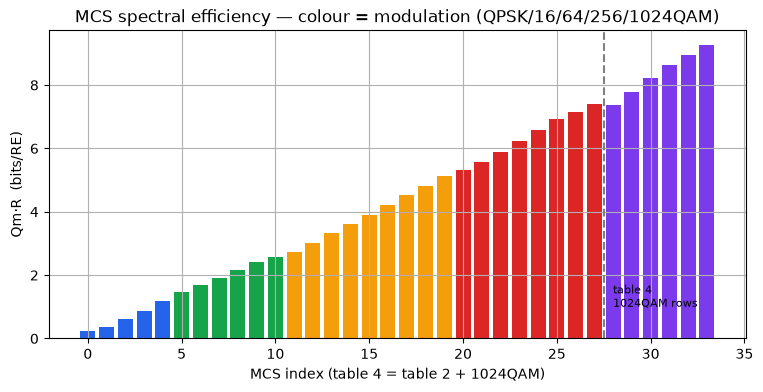

MCS 16 (table 2): 64QAM, R=0.702
TBS for 106 PRB, 2 layers = 118896 bits (14.9 kB) per slot
tiny allocation TBS (floor rule): 24


In [3]:
from nrdlsim import mcs_tables, tbs as tbs_mod

# spectral efficiency Qm*R across MCS table 4 (table 2 + 1024QAM rows)
idx = range(mcs_tables.num_mcs(4))
eff = [mcs_tables.get_mcs(i, 4).spectral_efficiency for i in idx]
qm  = [mcs_tables.get_mcs(i, 4).modulation_order for i in idx]
colors = {2:"#2563eb",4:"#16a34a",6:"#f59e0b",8:"#dc2626",10:"#7c3aed"}
plt.figure()
plt.bar(list(idx), eff, color=[colors[q] for q in qm])
plt.axvline(mcs_tables.num_mcs(2) - 0.5, ls="--", color="gray")
plt.text(mcs_tables.num_mcs(2), 1, "table 4\n1024QAM rows", fontsize=8)
plt.xlabel("MCS index (table 4 = table 2 + 1024QAM)"); plt.ylabel("Qm·R  (bits/RE)")
plt.title("MCS spectral efficiency — colour = modulation (QPSK/16/64/256/1024QAM)")
plt.show()

info = mcs_tables.get_mcs(16, 2)
print(f"MCS 16 (table 2): {info.modulation_name}, R={info.target_code_rate:.3f}")
n_re = tbs_mod.re_per_rb(13, 24, 0)              # 13 symbols, 24 DMRS RE, no overhead
tb = tbs_mod.compute_tbs(n_re, 106, info.modulation_order, info.target_code_rate, 2)
print(f"TBS for 106 PRB, 2 layers = {tb} bits ({tb/8/1e3:.1f} kB) per slot")

# small-TBS quantisation: N_info = 12 * 616/1024 * 4 = 28.875
#   n = 3, N'_info = 8*floor(3.6) = 24  ->  TBS 24   (rounding would give 32)
print("tiny allocation TBS (floor rule):", tbs_mod.compute_tbs(12, 1, 4, 616/1024, 1))

## 3 · `resource_grid.py` — resource grid & DM-RS overhead  *(TS 38.211 §7.4.1)*

The PDSCH does not fill the whole slot: **DM-RS** (demodulation reference
signals) occupy some resource elements for channel estimation. This module
counts the DM-RS overhead and the remaining data REs — which directly sets the
achievable throughput.

In [4]:
from nrdlsim import resource_grid as rg
from nrdlsim.config import DMRSConfig

pdsch = PDSCHConfig(num_rb=106, num_symbols=13, dmrs=DMRSConfig(additional_positions=1))
print("DM-RS OFDM symbol positions in slot:", rg.dmrs_symbol_positions(pdsch))
print(f"DM-RS REs per PRB      : {rg.dmrs_re_per_rb(pdsch)}")
print(f"data REs per PRB       : {rg.data_re_per_rb(pdsch)}")
print(f"DM-RS overhead fraction: {rg.dmrs_overhead_fraction(pdsch)*100:.1f}%")
print(f"total data REs (slot)  : {rg.num_data_re(pdsch)}")

DM-RS OFDM symbol positions in slot: [1, 7]
DM-RS REs per PRB      : 24
data REs per PRB       : 132
DM-RS overhead fraction: 15.4%
total data REs (slot)  : 13992


## 4 · `modulation.py` — QAM mapping & soft demapping  *(TS 38.211 §5.1)*

Gray-mapped QPSK / 16 / 64 / 256-QAM constellations (unit average energy) and a
**max-log-MAP soft demapper** that returns per-bit LLRs. The constellations are
built exactly from the TS 38.211 bit-to-symbol expressions. **1024QAM**
(Qm = 10, mean power 682 before normalisation) uses the same square-QAM
construction.

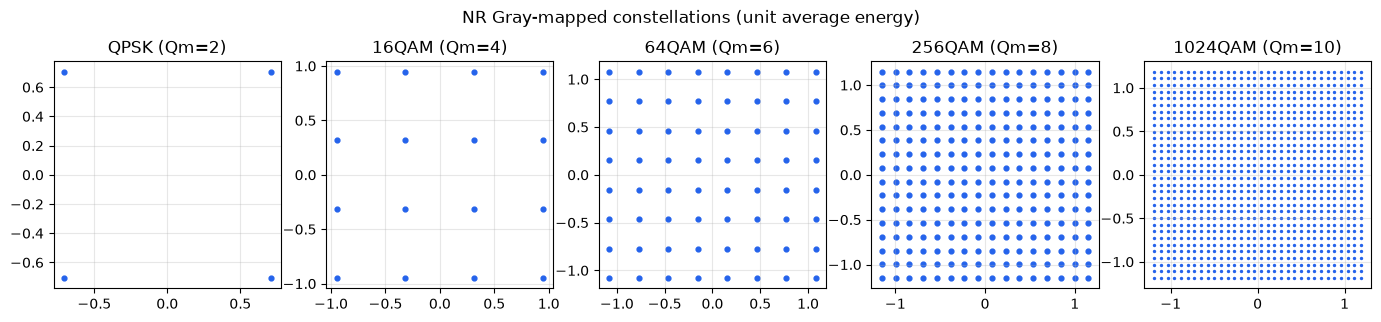

64QAM soft-demap bit error rate at high SNR: 0.008666666666666666


In [5]:
from nrdlsim.modulation import Modulator, _build_constellation

fig, axes = plt.subplots(1, 5, figsize=(17, 3.4))
for ax, (name, q) in zip(axes, [("QPSK",2),("16QAM",4),("64QAM",6),("256QAM",8),
                                ("1024QAM",10)]):
    c = _build_constellation(q)
    ax.scatter(c.real, c.imag, s=12 if q < 10 else 2, color="#2563eb")
    ax.set_title(f"{name} (Qm={q})"); ax.set_aspect("equal"); ax.grid(True, alpha=0.3)
plt.suptitle("NR Gray-mapped constellations (unit average energy)")
plt.show()

# soft demap: LLR sign recovers bits at high SNR
mod = Modulator(6)
bits = np.random.default_rng(0).integers(0, 2, 6*1000)
sym = mod.modulate(bits)
noise = 0.01
rx = sym + np.sqrt(noise/2)*(np.random.randn(sym.size)+1j*np.random.randn(sym.size))
llr = mod.demodulate_llr(rx, noise)
print("64QAM soft-demap bit error rate at high SNR:", np.mean((llr<0)!=bits))

## 5 · `channel_models.py` — TDL channel  *(TR 38.901 §7.7.2)*

**Tapped Delay Line** models TDL-A…E: a set of taps (delay, power) with
per-tap Rayleigh/Rician fading (sum-of-sinusoids Doppler) and a Kronecker
antenna-correlation MIMO extension. Below: the power-delay profile and the
resulting frequency-selective response.

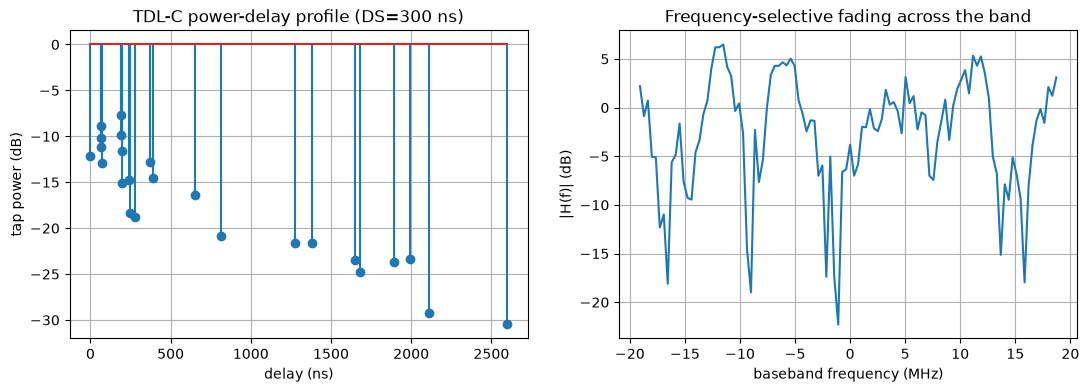

In [6]:
from nrdlsim.channel_models import TDLChannel

ch = TDLChannel("TDL-C", delay_spread_ns=300, max_doppler_hz=100,
                n_tx=2, n_rx=2, rng=np.random.default_rng(1))
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4))
a1.stem(ch.delays_s*1e9, 10*np.log10(ch.powers))
a1.set_xlabel("delay (ns)"); a1.set_ylabel("tap power (dB)")
a1.set_title("TDL-C power-delay profile (DS=300 ns)")

freqs = (np.arange(106)-53)*12*30e3
H = ch.frequency_response(freqs, 0.0)
a2.plot(freqs/1e6, 20*np.log10(np.abs(H[:,0,0])))
a2.set_xlabel("baseband frequency (MHz)"); a2.set_ylabel("|H(f)| (dB)")
a2.set_title("Frequency-selective fading across the band")
plt.show()

## 5b · `channel_models.py` — CDL channel, dual-pol UPA & antenna pattern  *(TR 38.901 §7.3/7.5/7.7.1)*

**Clustered Delay Line** models specify per-cluster **angles**
(AoD/AoA/ZoD/ZoA). The MIMO channel is synthesised geometrically from
**uniform planar array** steering vectors with the full **dual-polarized**
coefficient (2×2 cross-pol coupling + XPR), and each element can carry the
**3GPP directional radiation pattern** (Table 7.3-1).

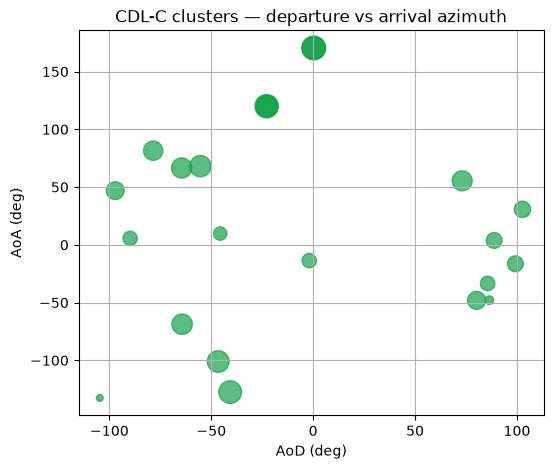

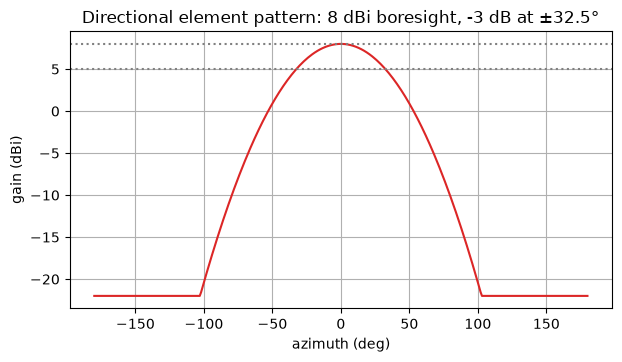

dual-pol UPA channel H shape [freq, rx, tx] = (106, 4, 8)


In [7]:
from nrdlsim.channel_models import CDLChannel, element_power_gain, _CDL

# cluster angular map (AoD vs AoA) for CDL-C, marker size ~ cluster power
cl = np.array(_CDL["CDL-C"]["clusters"])
plt.figure(figsize=(6,5))
plt.scatter(cl[:,2], cl[:,3], s=(cl[:,1]-cl[:,1].min()+2)*12, c="#16a34a", alpha=0.7)
plt.xlabel("AoD (deg)"); plt.ylabel("AoA (deg)")
plt.title("CDL-C clusters — departure vs arrival azimuth"); plt.show()

# 3GPP directional element pattern (Table 7.3-1), azimuth cut
az = np.linspace(-180, 180, 361)
g = 10*np.log10(element_power_gain(az, 90.0))
plt.figure(figsize=(7,3.6))
plt.plot(az, g, color="#dc2626")
plt.axhline(8, ls=":", color="gray"); plt.axhline(5, ls=":", color="gray")
plt.xlabel("azimuth (deg)"); plt.ylabel("gain (dBi)")
plt.title("Directional element pattern: 8 dBi boresight, -3 dB at ±32.5°")
plt.show()

# dual-pol UPA channel: 8 tx ports = 2x2 positions x 2 pol
ch = CDLChannel("CDL-C", 100, 100, n_tx=8, n_rx=4, tx_pol=2, rx_pol=2,
                tx_layout=(2,2), tx_pattern="38.901", downtilt_deg=8,
                rng=np.random.default_rng(0))
H = ch.frequency_response(freqs, 0.0)
print("dual-pol UPA channel H shape [freq, rx, tx] =", H.shape)

## 6 · `layer_mapping.py` — layer mapping & precoding  *(TS 38.211 §7.3.1)*

Codeword symbols are distributed across transmission layers (Table 7.3.1.3-1),
then mapped to antenna ports by a precoder. `svd_precoder` gives the
closed-loop eigen-beamforming precoder; open-loop uses an identity/DFT mapping.

In [8]:
from nrdlsim.layer_mapping import layer_map, svd_precoder, num_codewords

cw = [np.arange(12)]                       # one codeword, 12 symbols
layers = layer_map(cw, num_layers=2)
print("codewords for rank 2:", num_codewords(2), "| layer array shape:", layers.shape)

W = svd_precoder(H, num_layers=2)          # per-subcarrier precoder
print("SVD precoder W shape [freq, n_tx, layers] =", W.shape)
print("columns orthonormal? W^H W ≈ I:",
      np.allclose(W[0].conj().T @ W[0], np.eye(2), atol=1e-6))

codewords for rank 2: 1 | layer array shape: (2, 6)
SVD precoder W shape [freq, n_tx, layers] = (106, 8, 2)
columns orthonormal? W^H W ≈ I: True


## 7 · `ldpc.py` — DL-SCH coding chain  *(TS 38.212 §5, §7.2)*

The bit-true FEC: **CRC** attachment (24A/24B/16), code-block **segmentation**,
**base-graph** selection (BG1/BG2), a **QC-LDPC** encoder (NR base-graph
architecture: systematic part + dual-diagonal accumulator core), and a
normalised **min-sum** decoder. Here it demonstrates genuine coding gain.

In [9]:
from nrdlsim import ldpc as L
from nrdlsim.modulation import Modulator

code = L.build_code(bg=2, z=32)
print(f"QC-LDPC: BG2, Z=32 -> K={code.k_bits} info bits, N={code.n_bits} coded "
      f"(rate {code.k_bits/code.n_bits:.2f})")
mod = Modulator(2)
rng = np.random.default_rng(3)
def decode_rate(snr_db, trials=30):
    ok = 0; noise = np.sqrt(1/(2*10**(snr_db/10)))
    for _ in range(trials):
        info = rng.integers(0,2,code.k_bits).astype(np.int8)
        cw = L.encode(code, info)
        pad = (-cw.size) % 2
        tx = mod.modulate(np.concatenate([cw, np.zeros(pad, np.int8)]))
        rx = tx + noise*(rng.standard_normal(tx.size)+1j*rng.standard_normal(tx.size))
        llr = mod.demodulate_llr(rx, 2*noise**2)[:code.n_bits]
        hard, good = L.decode(code, llr, max_iter=25)
        ok += good and np.array_equal(hard[:code.k_bits], info)
    return ok/trials
print("decode success @ -6 dB:", decode_rate(-6.0))
print("decode success @ +6 dB:", decode_rate(+6.0), "  <- coding gain")

QC-LDPC: BG2, Z=32 -> K=320 info bits, N=1664 coded (rate 0.19)


decode success @ -6 dB: 0.0


decode success @ +6 dB: 1.0   <- coding gain


## 8 · `link_abstraction.py` — BICM capacity & MIESM

For fast full-curve sweeps the coded BLER is predicted from the per-RE SINRs.
The chain is: map each SINR to its **bit-interleaved coded-modulation (BICM)
mutual information**, compress across REs to an **effective SINR** (MIESM), then
apply an NR-LDPC BLER waterfall. The BICM capacity curves are shown below.

The waterfall is a logistic curve. Its 50 % point sits at the capacity SNR plus
a coding gap, and it gets steeper as the transport block gets longer.
`required_eff_sinr_db(qm, R, tbs, target)` is its **exact inverse**: the
effective SINR at which a given MCS reaches a target BLER. CQI selection (UE)
and MCS selection (gNB) both use this one function, so both work at the same
BLER target. An earlier version placed the CQI thresholds near the 50 % point,
which is about 38 % BLER.

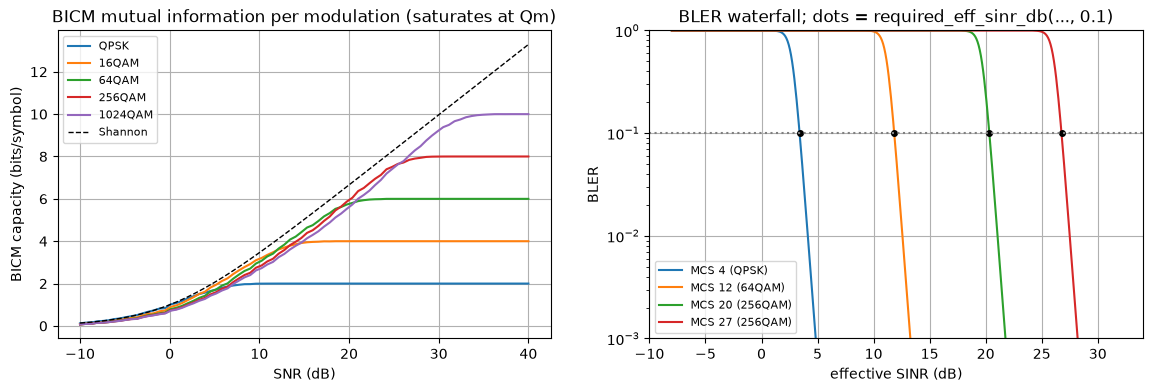

In [10]:
from nrdlsim.link_abstraction import (bicm_capacity, bler_from_effective_sinr,
                                      required_eff_sinr_db)
snr = np.linspace(-10, 40, 80)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 4))
for name, q in [("QPSK",2),("16QAM",4),("64QAM",6),("256QAM",8),("1024QAM",10)]:
    a1.plot(snr, bicm_capacity(snr, q), label=name)
a1.plot(snr, np.log2(1+10**(snr/10)), "k--", lw=1, label="Shannon")
a1.set_xlabel("SNR (dB)"); a1.set_ylabel("BICM capacity (bits/symbol)")
a1.set_title("BICM mutual information per modulation (saturates at Qm)")
a1.legend(fontsize=8)

# BLER waterfalls for a few MCS, with the 10 % operating point marked
tb = 20000
for mcs in (4, 12, 20, 27):
    i = mcs_tables.get_mcs(mcs, 2)
    s = np.linspace(-8, 32, 400)
    a2.semilogy(s, [bler_from_effective_sinr(x, i.modulation_order,
                                             i.target_code_rate, tb) for x in s],
                label=f"MCS {mcs} ({i.modulation_name})")
    s10 = required_eff_sinr_db(i.modulation_order, i.target_code_rate, tb, 0.1)
    a2.plot(s10, 0.1, "ko", ms=4)
a2.axhline(0.1, ls=":", color="gray")
a2.set_ylim(1e-3, 1); a2.set_xlabel("effective SINR (dB)"); a2.set_ylabel("BLER")
a2.set_title("BLER waterfall; dots = required_eff_sinr_db(..., 0.1)")
a2.legend(fontsize=8); plt.show()

## 9 · `csi.py` — CSI feedback: RI / PMI / CQI  *(TS 38.214 §5.2)*

From the estimated channel the UE selects the **rank (RI)** that maximises
throughput, the **precoder (PMI)** (SVD proxy for the codebook), and the
highest **CQI** meeting the BLER target. Reports are delayed by a configurable
number of slots to model the feedback loop.

How each rank hypothesis *r* is evaluated:

1. **Power split.** The precoder is applied as `W/√r`, the same total-power
   split the gNB uses when it transmits. Without it, a rank-*r* hypothesis
   would look 10·log₁₀(*r*) dB better than it really is: 3 dB at rank 2,
   6 dB at rank 4. That would push rank and CQI too high.
2. **Per-modulation effective SINR.** MIESM compression is done separately for
   each modulation order in the CQI table. Each CQI is then judged with its
   own modulation's mutual-information curve.
3. **CQI at the target BLER.** The CQI is the highest one whose effective SINR
   reaches `cqi_required_sinr_db(...)`. That threshold is where the CQI's
   (Qm, R) reaches the target BLER, using the TBS it would have on the CSI
   reference resource at this rank.
4. **Rank choice.** The rank with the highest *r*·SE(CQI) wins.

The report also keeps the precoder for **every** rank (`report.precoders`).
The gNB needs these because a HARQ retransmission must keep its original rank,
even if the UE now recommends a different one.

selected rank (RI)   : 3
reported CQI         : 8
effective SINR       : 13.5 dB
precoder shape (PMI) : (106, 8, 3)
precoders kept for ranks: [1, 2, 3, 4]
SINR of the transmitted signal: 13.5 dB  (matches the report)


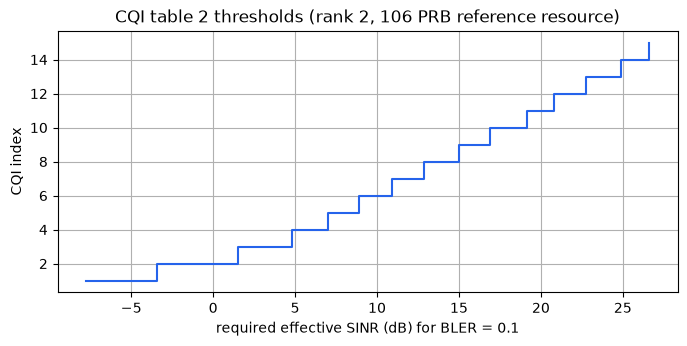

In [11]:
from nrdlsim.csi import compute_csi, cqi_required_sinr_db
from nrdlsim.link_abstraction import effective_sinr_miesm
from nrdlsim.receiver import batch_mmse_sinr

noise_var = 10**(-15/10)                    # 15 dB SNR
report = compute_csi(H, noise_var, max_rank=4, mcs_table=2, target_bler=0.1)
print(f"selected rank (RI)   : {report.rank}")
print(f"reported CQI         : {report.cqi}")
print(f"effective SINR       : {report.eff_sinr_db:.1f} dB")
print(f"precoder shape (PMI) : {report.precoder.shape}")
print(f"precoders kept for ranks: {sorted(report.precoders)}")

# the CSI SINR is the SINR of what is actually transmitted (W / sqrt(rank))
qm = mcs_tables.get_cqi(report.cqi, 2)[0]
W_tx = report.precoder / np.sqrt(report.rank)
eff_tx = effective_sinr_miesm(batch_mmse_sinr(H @ W_tx, noise_var).reshape(-1), qm)
print(f"SINR of the transmitted signal: {eff_tx:.1f} dB  (matches the report)")

# CQI thresholds: every CQI sits exactly at the 10 % BLER point
thr = cqi_required_sinr_db(2, 2, 0.1, 144, 106)      # CQI table 2, rank 2
plt.figure(figsize=(8, 3.4))
plt.step(thr, range(1, 16), where="post", color="#2563eb")
plt.xlabel("required effective SINR (dB) for BLER = 0.1"); plt.ylabel("CQI index")
plt.title("CQI table 2 thresholds (rank 2, 106 PRB reference resource)")
plt.show()

## 10 · `scheduler.py` — MCS scheduling & OLLA  *(TS 38.214)*

MCS selection works in the **SINR domain**:

1. **CQI → SINR.** The gNB turns the reported CQI back into its target-BLER
   SINR, using the same `cqi_required_sinr_db` table the UE used.
2. **Apply OLLA.** It subtracts the **outer-loop link adaptation (OLLA)**
   offset, in dB.
3. **SINR → MCS.** It picks the highest MCS whose own target-BLER SINR fits.
   The MCS table is finer than the CQI table, so this also interpolates
   between CQI steps.

OLLA corrects whatever bias the CQI has:

* It updates on **first-transmission** ACK/NACKs only. A NACK adds Δ = 0.5 dB
  of back-off. An ACK removes Δ·p/(1−p), which is 0.056 dB for p = 0.1.
* The drift is zero exactly when the NACK rate equals *p*, so the
  first-transmission BLER converges to the target.
* The offset can go **negative**, which makes the scheduler more aggressive.
  An earlier version clamped it at ≥ 0, so a pessimistic CQI could never be
  corrected. The offset is limited to ±10 dB.

The first demo shows OLLA's response to a NACK burst. The second shows OLLA
converging from a CQI that is 3 dB too optimistic and from one that is 3 dB too
pessimistic.

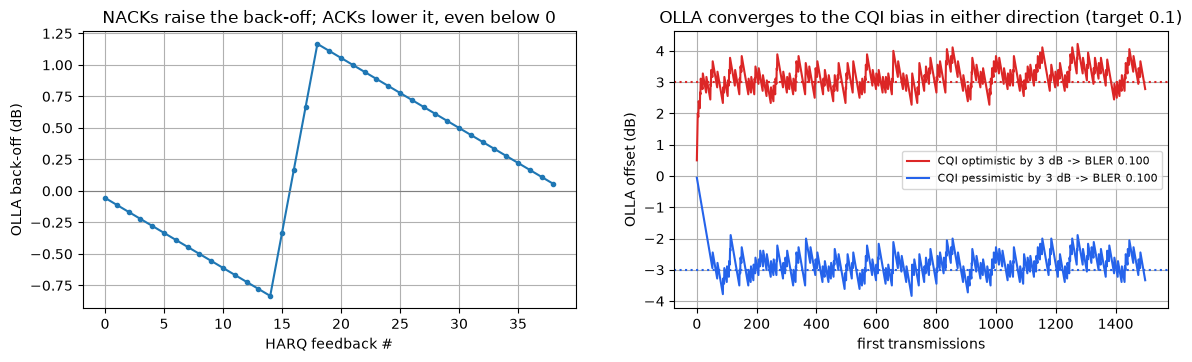

CQI 10, rank 2, OLLA offset -2 dB -> MCS 18
CQI 10, rank 2, OLLA offset +0 dB -> MCS 17
CQI 10, rank 2, OLLA offset +2 dB -> MCS 14


In [12]:
from nrdlsim.scheduler import Scheduler
from nrdlsim.csi import CSIReport

sched = Scheduler(total_rb=106, mcs_table=2, target_bler=0.1)
offsets = []
acks = [True]*15 + [False]*4 + [True]*20   # a NACK burst in the middle
for a in acks:
    sched.update_olla(a); offsets.append(sched.olla_offset)

# toy link: the true BLER is a waterfall in (CQI bias - OLLA offset)
def olla_trace(cqi_bias_db, n=1500, seed=0):
    rng = np.random.default_rng(seed)
    s = Scheduler(total_rb=106, mcs_table=2, target_bler=0.1)
    off, nack = [], []
    for _ in range(n):
        margin = s.olla_offset - cqi_bias_db          # dB of real headroom
        bler = 1 / (1 + np.exp(3.0 * (margin + np.log(9) / 3.0)))
        ack = rng.random() > bler
        s.update_olla(ack); off.append(s.olla_offset); nack.append(not ack)
    return np.array(off), np.array(nack)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 3.6))
a1.plot(offsets, marker="o", ms=3)
a1.axhline(0, color="gray", lw=0.8)
a1.set_xlabel("HARQ feedback #"); a1.set_ylabel("OLLA back-off (dB)")
a1.set_title("NACKs raise the back-off; ACKs lower it, even below 0")
for bias, col in [(+3, "#dc2626"), (-3, "#2563eb")]:
    off, nack = olla_trace(bias)
    a2.plot(off, color=col,
            label=f"CQI {'optimistic' if bias > 0 else 'pessimistic'} by 3 dB "
                  f"-> BLER {nack[500:].mean():.3f}")
a2.axhline(3, ls=":", color="#dc2626"); a2.axhline(-3, ls=":", color="#2563eb")
a2.set_xlabel("first transmissions"); a2.set_ylabel("OLLA offset (dB)")
a2.set_title("OLLA converges to the CQI bias in either direction (target 0.1)")
a2.legend(fontsize=8); plt.show()

# the same CQI maps to different MCS as the OLLA offset moves
rep = CSIReport(rank=2, cqi=10, precoder=None, eff_sinr_db=0.0)
for o in (-2.0, 0.0, 2.0):
    sched.olla_offset = o
    print(f"CQI 10, rank 2, OLLA offset {o:+.0f} dB -> MCS {sched.schedule(rep, None, 2).mcs_index}")

## 11 · `receiver.py` — MMSE MIMO equalisation

The receiver estimates the channel from DM-RS and applies an **MMSE** equaliser,
returning per-layer post-equaliser SINRs that feed the LLRs / link abstraction.
`batch_mmse_sinr` processes the whole allocation in a few batched matrix ops.
The precoder carries the total-power split `W/√rank`: SNR is total Es/N0, so
two layers share the power that one layer would get.

In [13]:
from nrdlsim.receiver import batch_mmse_sinr
W2 = svd_precoder(H, 2) / np.sqrt(2)        # 2 layers share the transmit power
H_eff = H @ W2                              # [freq, n_rx, layers]
sinr = batch_mmse_sinr(H_eff, noise_var)   # [freq, layers]
print("per-layer post-MMSE SINR (dB): layer0 = %.1f, layer1 = %.1f (mean over band)"
      % (10*np.log10(sinr[:,0].mean()), 10*np.log10(sinr[:,1].mean())))

per-layer post-MMSE SINR (dB): layer0 = 20.8, layer1 = 15.9 (mean over band)


## 12 · `ofdm.py` — time-domain OFDM waveform  *(TS 38.211 §5.3)*

The sample-level path: grid → IFFT + cyclic prefix → RF impairments (**CFO**,
**timing offset**) + multipath → CP removal + FFT. It captures effects the
frequency-domain path abstracts away: a CFO drives the effective SINR down to
the analytic inter-carrier-interference ceiling, and a timing error is harmless
inside the CP but ISI-limited beyond it.

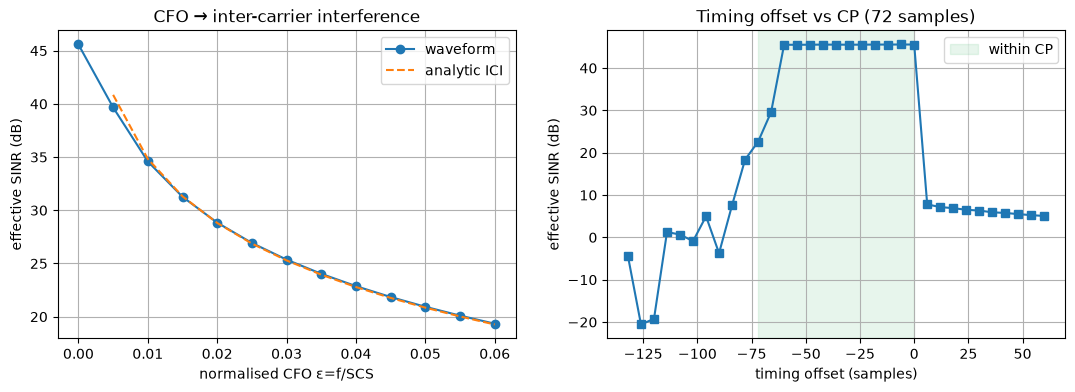

In [14]:
from nrdlsim.ofdm import OFDMModulator, waveform_evm, cfo_ici_sinr_db
mod = OFDMModulator(n_rb=51, scs_hz=30e3, mu=1); cp = int(mod.cp[1])
g = ((np.random.default_rng(0).integers(0,2,(mod.n_sc,mod.n_sym))*2-1)
     + 1j*(np.random.default_rng(1).integers(0,2,(mod.n_sc,mod.n_sym))*2-1))/np.sqrt(2)
h = np.zeros(20, complex); h[0]=1; h[5]=0.5; h[12]=0.3j

eps = np.linspace(0, 0.06, 13)
sinr = [waveform_evm(mod, g, 45, cfo_hz=e*30e3, h_time=h,
                     rng=np.random.default_rng(1))[1] for e in eps]
ceil = [cfo_ici_sinr_db(e*30e3, 30e3) if e>0 else np.nan for e in eps]
offs = np.arange(-cp-60, 61, 6)
sto = [waveform_evm(mod, g, 45, timing_offset=int(t), h_time=h,
                    rng=np.random.default_rng(2))[1] for t in offs]
fig,(a1,a2)=plt.subplots(1,2,figsize=(13,4))
a1.plot(eps, sinr, "o-", label="waveform"); a1.plot(eps, ceil, "--", label="analytic ICI")
a1.set_xlabel("normalised CFO ε=f/SCS"); a1.set_ylabel("effective SINR (dB)")
a1.set_title("CFO → inter-carrier interference"); a1.legend()
a2.plot(offs, sto, "s-"); a2.axvspan(-cp,0, color="#16a34a", alpha=0.1, label="within CP")
a2.set_xlabel("timing offset (samples)"); a2.set_ylabel("effective SINR (dB)")
a2.set_title(f"Timing offset vs CP ({cp} samples)"); a2.legend()
plt.show()

## 13 · `link_simulator.py` — full chain & spectral efficiency

`NRDownlinkSimulator` ties every module together, loops over slots with HARQ and
link adaptation, and outputs the spectral efficiency.

* **Spectral efficiency** is throughput divided by the **allocated** bandwidth,
  `num_rb·12·SCS`. A `num_rb` larger than the carrier grid is rejected.
* **HARQ** uses a single process with chase combining. A retransmission keeps
  its transport block's **rank, MCS and TBS**. It takes the precoder for that
  rank from the latest (delayed) CSI report, and its per-RE SINR is added to
  the earlier attempts'.
* **Two BLERs are reported:**
  * `bler` is the **first-transmission** BLER, the quantity OLLA drives to the
    target.
  * `residual_bler` is the fraction of transport blocks still lost after
    `max_transmissions`.
* **The config is never modified**, so `run(n_jobs=1)` and `run(n_jobs=-1)`
  give bit-identical results.

Here is a full SNR sweep for a 4×2 TDL-C link (256QAM, link adaptation on).
OLLA takes a few hundred slots to settle, so short runs sit slightly above
the 0.1 target. They converge to it over longer runs.

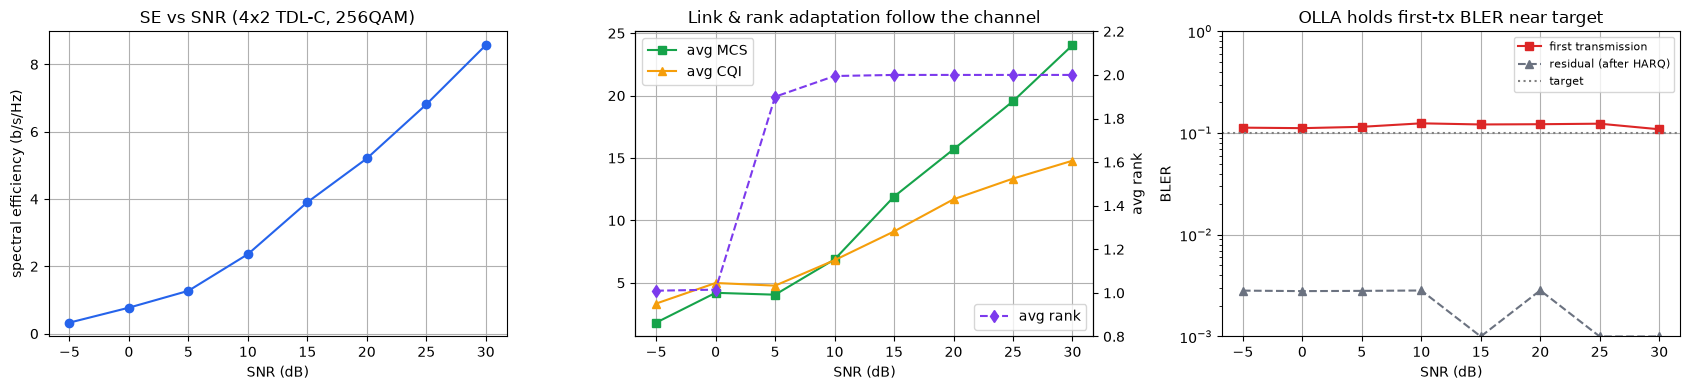

peak SE = 8.57 b/s/Hz at 30 dB


In [15]:
from nrdlsim.config import SimConfig, HARQConfig
from nrdlsim.link_simulator import NRDownlinkSimulator

cfg = SimConfig(
    carrier=CarrierConfig(mu=1, n_size_grid=51),
    pdsch=PDSCHConfig(num_rb=51, num_layers=2, mcs_table=2),
    antenna=AntennaConfig(n_tx=4, n_rx=2),
    channel=ChannelConfig(model="TDL-C", delay_spread_ns=100, max_doppler_hz=100),
    snr_db_range=(-5, 30, 5), num_slots=400)
results = NRDownlinkSimulator(cfg).run(n_jobs=-1)   # parallel across SNR points

snrs = [r.snr_db for r in results]
se   = [r.spectral_efficiency for r in results]
fig,(a1,a2,a3)=plt.subplots(1,3,figsize=(17,4))
a1.plot(snrs, se, "o-", color="#2563eb"); a1.set_xlabel("SNR (dB)")
a1.set_ylabel("spectral efficiency (b/s/Hz)"); a1.set_title("SE vs SNR (4x2 TDL-C, 256QAM)")
a2.plot(snrs, [r.avg_mcs for r in results], "s-", color="#16a34a", label="avg MCS")
a2.plot(snrs, [r.avg_cqi for r in results], "^-", color="#f59e0b", label="avg CQI")
a2b = a2.twinx(); a2b.plot(snrs, [r.avg_rank for r in results], "d--", color="#7c3aed",
                           label="avg rank")
a2b.set_ylabel("avg rank"); a2b.set_ylim(0.8, 2.2); a2b.grid(False)
a2.set_xlabel("SNR (dB)"); a2.set_title("Link & rank adaptation follow the channel")
a2.legend(loc="upper left"); a2b.legend(loc="lower right")
a3.semilogy(snrs, [r.bler for r in results], "s-", color="#dc2626",
            label="first transmission")
a3.semilogy(snrs, np.clip([r.residual_bler for r in results], 1e-3, 1), "^--",
            color="#6b7280", label="residual (after HARQ)")
a3.axhline(cfg.pdsch.target_bler, ls=":", color="gray", label="target")
a3.set_ylim(1e-3, 1); a3.set_xlabel("SNR (dB)"); a3.set_ylabel("BLER")
a3.set_title("OLLA holds first-tx BLER near target"); a3.legend(fontsize=8)
plt.tight_layout(); plt.show()
print(f"peak SE = {max(se):.2f} b/s/Hz at {snrs[int(np.argmax(se))]:.0f} dB")

In [16]:
# the simulator leaves the config untouched, so serial == parallel
import copy
cfg_small = copy.deepcopy(cfg); cfg_small.snr_db_range = (5, 25, 10); cfg_small.num_slots = 60
snapshot = copy.deepcopy(cfg_small)
ser = NRDownlinkSimulator(cfg_small).run(n_jobs=1)
par = NRDownlinkSimulator(copy.deepcopy(snapshot)).run(n_jobs=-1)
print("config unchanged after run :", cfg_small == snapshot)
print("serial == parallel results :", ser == par)

config unchanged after run : True
serial == parallel results : True


## 14 · Validation & calibration

The simulator is validated at three levels:

* **Component self-tests** (`tests/test_modules.py`): constellation energy,
  noiseless modulation round-trip, TDL/CDL power, BICM monotonicity, genuine
  LDPC coding gain, dual-pol/UPA power, antenna pattern, OFDM loopback/CP/CFO.
* **Link-adaptation regression tests** (`tests/test_link_adaptation.py`) check
  that:
  * the CSI SINR equals the SINR of what is actually transmitted;
  * the CQI/MCS thresholds invert the BLER waterfall;
  * OLLA moves in both directions and has zero drift at the target;
  * the first-transmission BLER converges to targets of 0.1 and 0.3;
  * the config is untouched and serial sweeps equal parallel ones;
  * SE is computed over the allocated bandwidth;
  * TBS quantisation follows the spec;
  * MCS table 4 works under link adaptation;
  * HARQ accounting separates first-transmission and residual BLER.
* **Analytical calibration** (`tests/validate_ber.py`): uncoded QAM BER matches
  the closed-form AWGN theory.
* **3GPP / 5G-IA calibration** (`examples/calibration_5gia.py`,
  `docs/calibration.md`): SNR at 70 % throughput vs the **5G-IA** ideal
  calibration and the **3GPP TS 38.104** requirements. The simulator tracks
  case-to-case behaviour to **~0.65 dB** (bias-removed) across QPSK/16QAM/64QAM,
  TDL-A/B/C and SIMO/2×2 MIMO.

| | vs 5G-IA (ideal) | vs 3GPP TS 38.104 |
|---|---|---|
| mean Δ | −1.33 dB | −3.43 dB |
| bias-removed spread | 0.64 dB | 0.69 dB |

## 15 · Performance & the module map

The simulator is vectorised and parallel: batched per-RB linear algebra, a
disk-cached BICM table, `run(n_jobs=-1)` / `--jobs` for parallel sweeps, and a
fast path that skips the CSI search under fixed-MCS. The 9-case calibration
runs in ~2 s.

### Module map

| Module | Role | Spec |
|--------|------|------|
| `config` | numerology, PDSCH/antenna/channel/HARQ configuration | 38.211 §4 |
| `mcs_tables`, `tbs` | MCS/CQI tables (incl. illustrative 1024QAM table 4), transport block size | 38.214 §5.1.3 |
| `resource_grid` | resource grid + DM-RS overhead | 38.211 §7.4.1 |
| `modulation` | QAM mapping + soft LLR demapping | 38.211 §5.1 |
| `channel_models` | TDL + CDL, dual-pol UPA, element pattern | 38.901 §7.3/7.5/7.7 |
| `layer_mapping` | codeword→layer mapping + precoding | 38.211 §7.3.1 |
| `ldpc` | DL-SCH LDPC coding chain | 38.212 §5, §7.2 |
| `link_abstraction` | BICM capacity, MIESM, LDPC BLER + its target-BLER inverse | — |
| `csi` | CSI feedback RI/PMI/CQI (power-split, target-BLER CQI) + delay | 38.214 §5.2 |
| `scheduler` | CQI→SINR→MCS, bidirectional OLLA in dB | 38.214 |
| `receiver` | DM-RS estimation + MMSE equalisation | — |
| `ofdm` | time-domain CP-OFDM + CFO/timing | 38.211 §5.3 |
| `link_simulator` | full chain, HARQ (TB kept across retx), SE over allocated BW | — |

**Run it from the CLI:**
```bash
python run_simulation.py --model CDL-C --snr -5 30 1 --slots 500 --jobs -1 --plot
python run_simulation.py --mcs-table 4 --snr 20 45 5 --ideal-csi   # with 1024QAM
python examples/calibration_5gia.py       # 3GPP / 5G-IA calibration
python tests/test_modules.py              # component self-tests
python tests/test_link_adaptation.py      # link-adaptation regression tests
```

The CLI prints `BLER1st` (first-transmission BLER) and `resBLER` (residual BLER
after HARQ) as separate columns.